In [1]:
pip install medmnist

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.8 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256

In [260]:
from medmnist import OCTMNIST
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Loading the dataset
data = OCTMNIST(split="train")
train_images, train_labels = data.imgs, data.labels

test_dataoct = OCTMNIST(split="test")
test_images, test_labels = test_dataoct.imgs, test_dataoct.labels
df=pd.DataFrame(train_labels)
print(f"Training images shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")
df.describe()

Training images shape: (97477, 28, 28)
Training labels shape: (97477, 1)
Test images shape: (1000, 28, 28)
Test labels shape: (1000, 1)


,0
count,97477.000000
mean,1.680386
std,1.359720
min,0.000000
25%,0.000000
50%,2.000000
75%,3.000000
max,3.000000


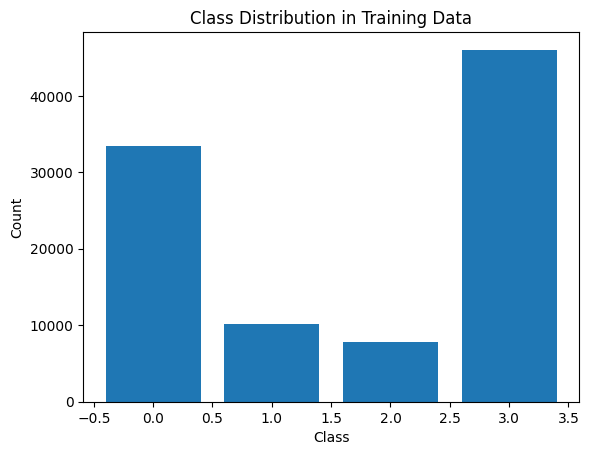

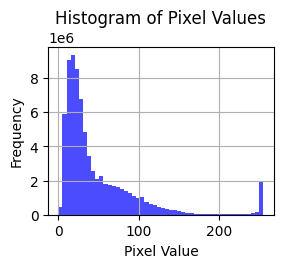

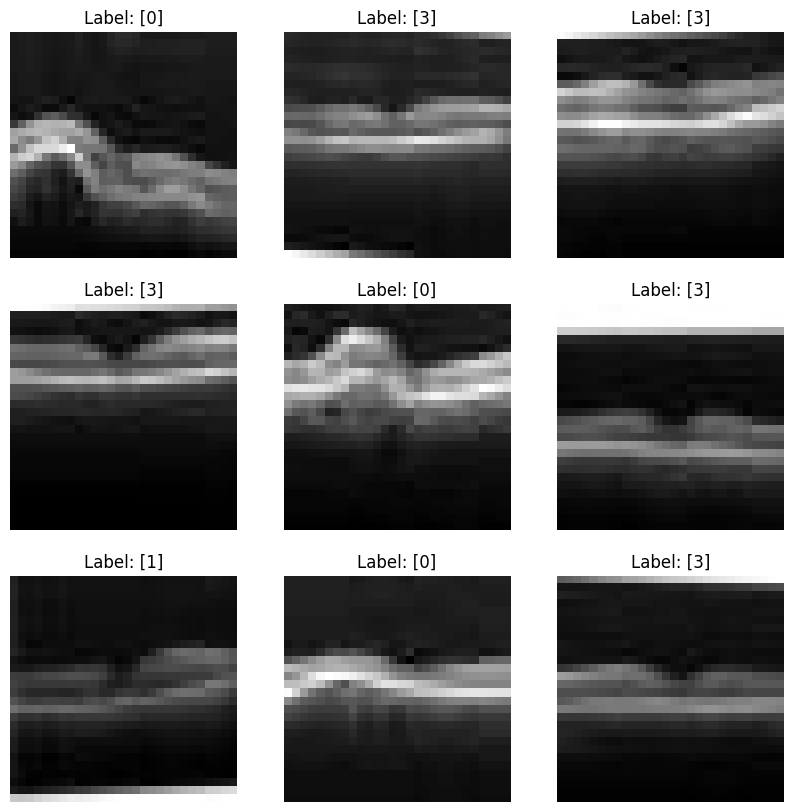

In [261]:
unique, counts = np.unique(train_labels, return_counts=True)
plt.bar(unique, counts)
plt.title("Class Distribution in Training Data")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

all_pixels = train_images.flatten()
plt.subplot(2, 2, 3)
plt.hist(all_pixels, bins=50, color="blue", alpha=0.7)
plt.title("Histogram of Pixel Values")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.grid(True)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(f"Label: {train_labels[i]}")
    plt.axis("off")
plt.show()

In [262]:
train_imgs = train_images / 255.0
test_imgs = test_images / 255.0

In [263]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
train_labels = encoder.fit_transform(train_labels.reshape(-1, 1))
test_labels = encoder.transform(test_labels.reshape(-1, 1))

In [264]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)
X_test, y_test = test_images, test_labels

In [265]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
# Checking GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class OCT_CNNMODEL(nn.Module):
    def __init__(self):
        super(OCT_CNNMODEL, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)  # Flatten the tensor
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Moving the model to the GPU
model = OCT_CNNMODEL().to(device)

Using device: cuda


In [266]:
# Converting the  sparse labels to dense format
if hasattr(train_labels, "toarray"):  # Checking whether it's a sparse matrix
    train_labels = train_labels.toarray()
    test_labels = test_labels.toarray()
# If labels are one-hot encoded, convert them to class indices
    if train_labels.shape[1] > 1:  # Checking if one-hot encoded
        train_labels = train_labels.argmax(axis=1)
        test_labels = test_labels.argmax(axis=1)

# Converting numpy arrays to PyTorch tensors
train_images_tensor = torch.tensor(train_imgs, dtype=torch.float32).unsqueeze(1)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.long)
test_images_tensor = torch.tensor(test_imgs, dtype=torch.float32).unsqueeze(1)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.long)

# Creating TensorDataset and DataLoader
train_dataset = TensorDataset(train_images_tensor, train_labels_tensor)
test_dataset = TensorDataset(test_images_tensor, test_labels_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [267]:
# Creating validation DataLoader
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
y_val_tensor = torch.tensor(y_val.toarray().argmax(axis=1), dtype=torch.long)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [268]:
import torch.optim as optim
# Defining loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
# Training loop
n_epochs = 10
for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        # Moveing data to GPU
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch [{epoch + 1}/{n_epochs}], Loss: {running_loss / len(train_loader)}")

Epoch [1/10], Loss: 0.9422948321723562
Epoch [2/10], Loss: 0.7288589477539062
Epoch [3/10], Loss: 0.6545202579750163
Epoch [4/10], Loss: 0.6070578117901337
Epoch [5/10], Loss: 0.5713969594615651
Epoch [6/10], Loss: 0.5444769559921868
Epoch [7/10], Loss: 0.5213559861160483
Epoch [8/10], Loss: 0.5059039426620394
Epoch [9/10], Loss: 0.4911235280608724
Epoch [10/10], Loss: 0.48104644054424733


In [269]:
from sklearn.metrics import accuracy_score
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        # Moving data to GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        # Storing predictions and labels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
# Calculating accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 62.00%


In [270]:
import torch.nn as nn
import torch.nn.functional as F

class ImprovedOCT_CNN(nn.Module):
    def __init__(self):
        super(ImprovedOCT_CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)#Batch normalization after conv1
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)# Batch normalization after conv2
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.bn3 = nn.BatchNorm1d(128)#Batch normalization after fc1
        self.dropout = nn.Dropout(0.1)  # Dropout layer
        self.fc2 = nn.Linear(128, 4)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        # Flatten the tensor
        x = x.view(-1, 64 * 7 * 7)
        x = self.fc1(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.dropout(x)  # Applying dropout
        # Output layer
        x = self.fc2(x)
        return x

In [271]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [272]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Initializing the model, optimizer, and loss function
model = ImprovedOCT_CNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

# Initializing early stopping
early_stop = EarlyStopping(patience=3, min_delta=0.01)

# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {running_loss / len(train_loader)}, Val Loss: {val_loss}")

    # Checking early stopping
    early_stop(val_loss)
    if early_stop.early_stop:
        print("Early stopping triggered")

Epoch [1/20], Loss: 0.5654074899910941, Val Loss: 156.69962901131052
Epoch [2/20], Loss: 0.3951753497886376, Val Loss: 104.17829254650678
Epoch [3/20], Loss: 0.3469069238136134, Val Loss: 82.01399927608303
Epoch [4/20], Loss: 0.3130201042246005, Val Loss: 86.39299895489802
Epoch [5/20], Loss: 0.28591727574901005, Val Loss: 163.88596906818327
Epoch [6/20], Loss: 0.2663344738618752, Val Loss: 57.38463930849169
Epoch [7/20], Loss: 0.24732432383041722, Val Loss: 85.608156104166
Epoch [8/20], Loss: 0.22892467085800067, Val Loss: 57.27917257840516
Epoch [9/20], Loss: 0.2136092660484195, Val Loss: 65.50317853083376
Epoch [10/20], Loss: 0.20019063492381353, Val Loss: 51.1795847251767
Epoch [11/20], Loss: 0.1902273055728222, Val Loss: 72.75239780613633
Epoch [12/20], Loss: 0.17857864637934942, Val Loss: 65.0690137706819
Epoch [13/20], Loss: 0.1662681247437681, Val Loss: 57.86916440744869
Early stopping triggered
Epoch [14/20], Loss: 0.1556877045381296, Val Loss: 63.77887626397805
Early stopping

In [273]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculating accuracy
accuracy_improved_model = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {accuracy_improved_model * 100:.2f}%")

Test Accuracy: 72.00%


In [274]:
# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
num_epochs = 10
# Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        # Calculate training accuracy
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Validation phase
    model.eval()
    val_loss = 0.0
    test_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Calculates validation accuracy
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = correct_val / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {train_loss}, Val Loss: {val_loss}, Train Acc: {train_accuracy}, Val Acc: {val_accuracy}")

Epoch [1/10], Train Loss: 0.10253262293483485, Val Loss: 84.43748228354532, Train Acc: 0.9651199770202201, Val Acc: 0.7152236356175625
Epoch [2/10], Train Loss: 0.09611944747438503, Val Loss: 85.82378012235047, Train Acc: 0.9673153667018887, Val Acc: 0.7336889618383258
Epoch [3/10], Train Loss: 0.09237028728361459, Val Loss: 99.7830798665031, Train Acc: 0.9687310852816562, Val Acc: 0.740716044316783
Epoch [4/10], Train Loss: 0.08742220393012906, Val Loss: 102.44097496407932, Train Acc: 0.9706289688849677, Val Acc: 0.687320475995076
Epoch [5/10], Train Loss: 0.08325599037841686, Val Loss: 100.6108913734311, Train Acc: 0.9722498640704987, Val Acc: 0.7410750923266312
Epoch [6/10], Train Loss: 0.07991976536849509, Val Loss: 91.99278137332104, Train Acc: 0.9733373000810448, Val Acc: 0.7268157570783751
Epoch [7/10], Train Loss: 0.0765717332856363, Val Loss: 102.55840978153417, Train Acc: 0.9733988530627737, Val Acc: 0.7253795650389824
Epoch [8/10], Train Loss: 0.07184735604004538, Val Loss: 

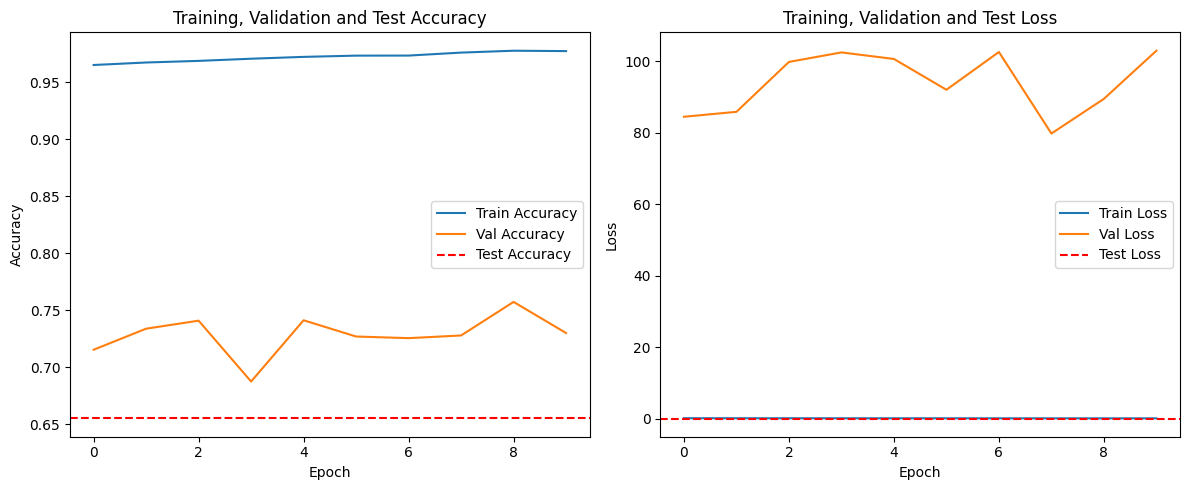

In [275]:
# Plotting training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.axhline(y=test_accuracy, color="r", linestyle="--", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training, Validation and Test Accuracy")
plt.legend()

# Plotting training and validation loss
plt.subplot(1, 2, 2)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.axhline(y=test_loss, color="r", linestyle="--", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training, Validation and Test Loss")
plt.legend()
plt.tight_layout()
plt.show()

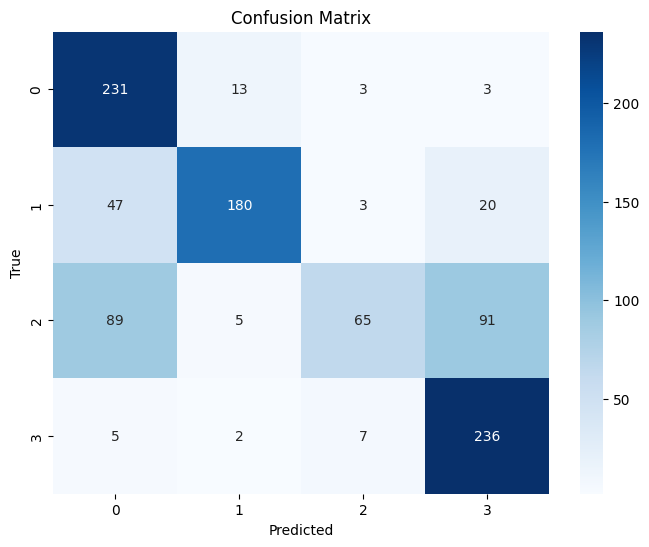

In [252]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

#confusion matrix
cm = confusion_matrix(all_labels, all_preds)
# Plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(4), yticklabels=range(4))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

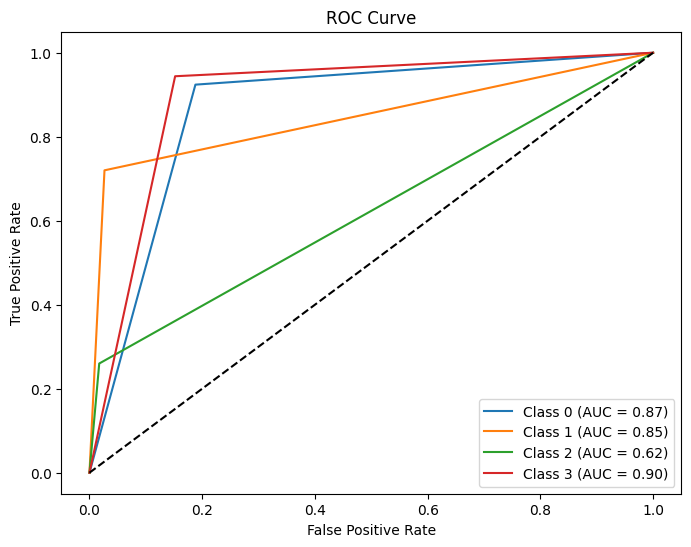

In [253]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
# Binarizing the labels for multi-class ROC
y_test_bin = label_binarize(all_labels, classes=[0, 1, 2, 3])
y_pred_bin = label_binarize(all_preds, classes=[0, 1, 2, 3])
# Computing the ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plotting ROC curve
plt.figure(figsize=(8, 6))
for i in range(4):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [198]:
torch.save(model.state_dict(), "a0_part_3_meerahus.pt")

In [259]:
"References:https://pytorch.org/tutorials/beginner/introyt/introyt_index.html, https://medmnist.com/,https://seaborn.pydata.org/generated/seaborn.heatmap.html,https://www.geeksforgeeks.org/how-to-handle-overfitting-in-pytorch-models-using-early-stopping/,https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html"

'References:https://pytorch.org/tutorials/beginner/introyt/introyt_index.html, https://medmnist.com/,https://seaborn.pydata.org/generated/seaborn.heatmap.html,https://www.geeksforgeeks.org/how-to-handle-overfitting-in-pytorch-models-using-early-stopping/,https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html'